In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# numerical columns
numerical_cols = df.select_dtypes(include='number').columns
print("Numerical columns:", list(numerical_cols))

# categorical columns
categorical_cols = df.select_dtypes(exclude='number').columns
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']


In [ ]:
print("Mean of tip:", df['tip'].mean())

Mean of tip: 2.99827868852459


In [ ]:
print("Value counts of sex:")
print(df['sex'].value_counts())

Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


In [ ]:
tip = df['tip']

print("Mean  :", round(tip.mean(), 2))
print("Median:", round(tip.median(), 2))
print("Mode  :", round(tip.mode()[0], 2))

Mean  : 3.0
Median: 2.9
Mode  : 2.0


In [ ]:
print("mean > median ?", tip.mean() > tip.median())

mean > median ? True


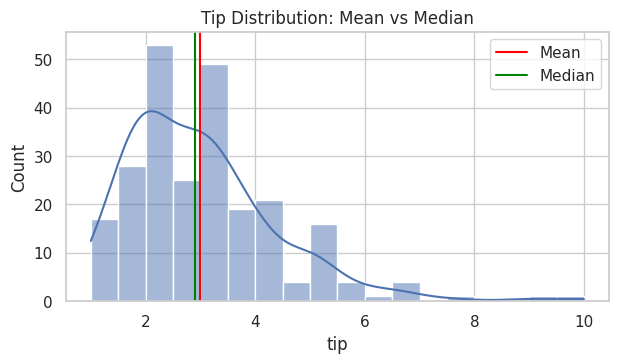

In [ ]:
plt.figure(figsize=(7, 3.5))

sns.histplot(tip, kde=True)

plt.axvline(tip.mean(), color='red', label='Mean')
plt.axvline(tip.median(), color='green', label='Median')

plt.legend()
plt.title("Tip Distribution: Mean vs Median")
plt.show()

In [ ]:
col = df['total_bill']

print('Range :', col.max() - col.min())
print('Var   :', col.var())
print('Std   :', col.std())

Range : 47.74
Var   : 79.25293861397826
Std   : 8.902411954856856


In [ ]:
q1 = col.quantile(0.25)
q3 = col.quantile(0.75)
iqr = q3 - q1

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)

Q1: 13.3475
Q3: 24.127499999999998
IQR: 10.779999999999998


Five-number summary:
min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


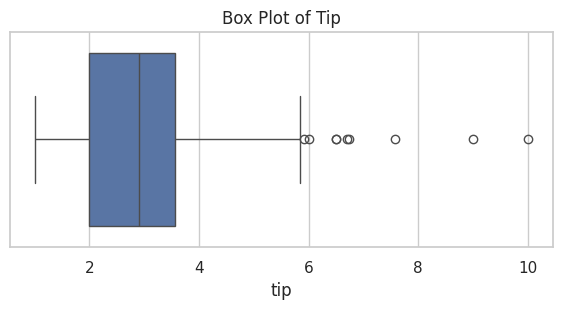


Correlation matrix (rounded):
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

Correlation total_bill vs tip: 0.68


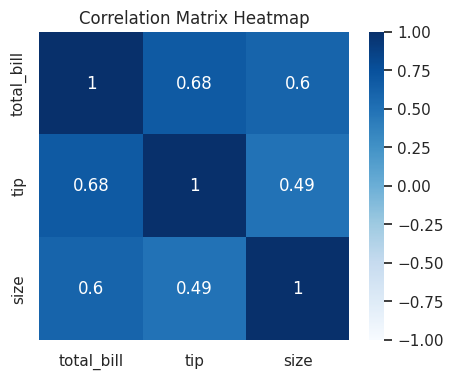


Dataset Summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [ ]:
# -----------------------------------------------------------
# LAB 4 & 5 — FULL CODE
# -----------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Load dataset
df = sns.load_dataset('tips')

# -----------------------------------------------------------
# 🔹 LAB 4A: FIVE-NUMBER SUMMARY + SKEWNESS
# -----------------------------------------------------------

tip = df['tip']

five_num = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print("Five-number summary:")
print(five_num)

print("\nSkewness:", round(tip.skew(), 3))
# If skewness > 0 → right skew
# If skewness < 0 → left skew

# -----------------------------------------------------------
# 🔹 LAB 4B: BOX PLOT
# -----------------------------------------------------------

plt.figure(figsize=(7, 2.8))
sns.boxplot(x=tip)
plt.title("Box Plot of Tip")
plt.show()

# -----------------------------------------------------------
# 🔹 LAB 5A: CORRELATION MATRIX
# -----------------------------------------------------------

corr = df.corr(numeric_only=True)
print("\nCorrelation matrix (rounded):")
print(corr.round(2))

print("\nCorrelation total_bill vs tip:",
      round(corr.loc['total_bill', 'tip'], 2))

# -----------------------------------------------------------
# 🔹 LAB 5B: HEATMAP
# -----------------------------------------------------------

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

# -----------------------------------------------------------
# 🔹 LAB 5C: DATA SUMMARY
# -----------------------------------------------------------

print("\nDataset Summary:")
print(df.describe())

# Insights (write as comments in exam/assignment):
# Insight 1: total_bill has higher spread than tip (std is larger)
# Insight 2: total_bill and tip show positive correlation
# Insight 3: data shows mild right skew in monetary variables

In [ ]:
# Simulate 100,000 pairs of coin flips
flips = np.random.randint(0, 2, size=(100_000, 2))

# Number of heads in each pair
heads = flips.sum(axis=1)

# --------------------------------------------------
# 1. P(both heads)
# --------------------------------------------------
p_both_heads = (heads == 2).mean()

print("P(both heads) =", round(p_both_heads, 3))

# --------------------------------------------------
# 2. P(at least one head)
# --------------------------------------------------
p_at_least_one = (heads >= 1).mean()

print("P(at least one head) =", round(p_at_least_one, 3))

# --------------------------------------------------
# 3. Check addition rule
# P(0 heads) + P(1 head) + P(2 heads)
# --------------------------------------------------
p_0 = (heads == 0).mean()
p_1 = (heads == 1).mean()
p_2 = (heads == 2).mean()

print("P(0 heads) =", round(p_0, 3))
print("P(1 head)  =", round(p_1, 3))
print("P(2 heads) =", round(p_2, 3))

print("Sum =", round(p_0 + p_1 + p_2, 3))

P(both heads) = 0.25
P(at least one head) = 0.749
P(0 heads) = 0.251
P(1 head)  = 0.5
P(2 heads) = 0.25
Sum = 1.0


In [ ]:
# -----------------------------------------------------------
# LAB EXERCISE 2 — Conditional Probability
# -----------------------------------------------------------

import numpy as np

# Fresh dice rolls
rolls = np.random.randint(1, 7, size=100_000)

# -----------------------------------------------------------
# 1. P(odd | roll < 4)
# -----------------------------------------------------------

less_than_4 = rolls[rolls < 4]      # condition on roll < 4
p_odd_given_lt4 = (less_than_4 % 2 == 1).mean()

print("P(odd | roll < 4) =", round(p_odd_given_lt4, 3))

# -----------------------------------------------------------
# 2. P(roll < 4)
# -----------------------------------------------------------

p_lt4 = (rolls < 4).mean()

print("P(roll < 4) =", round(p_lt4, 3))

# -----------------------------------------------------------
# 3. Compare P(odd | <4) with P(odd)
# -----------------------------------------------------------

p_odd = (rolls % 2 == 1).mean()

print("P(odd) =", round(p_odd, 3))
print("P(odd | roll < 4) =", round(p_odd_given_lt4, 3))

print("Independent?",
      np.isclose(p_odd_given_lt4, p_odd, atol=0.02))

# Comment:
# If P(odd | roll < 4) ≈ P(odd), then the events are independent.
# Otherwise, they are dependent.

P(odd | roll < 4) = 0.662
P(roll < 4) = 0.501
P(odd) = 0.498
P(odd | roll < 4) = 0.662
Independent? False


In [ ]:
# -----------------------------------------------------------
# LAB EXERCISE 3 — Bayes Spam Filter
# -----------------------------------------------------------

# 1. Priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

# P(ham)
p_ham = 1 - p_spam

# -----------------------------------------------------------
# 2. P('free') using Total Probability
# -----------------------------------------------------------

p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_ham * p_ham)

print("P('free') =", round(p_free, 3))

# -----------------------------------------------------------
# 3. Bayes: P(spam | 'free')
# -----------------------------------------------------------

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("P(spam | 'free') =", round(p_spam_given_free, 3))

# Interpretation:
# If an email contains "free",
# there is about a 75% chance it is spam.

P('free') = 0.16
P(spam | 'free') = 0.75


Sample Mean = 2.009


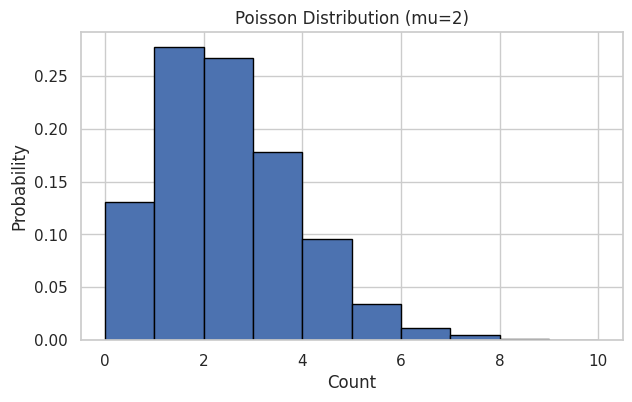

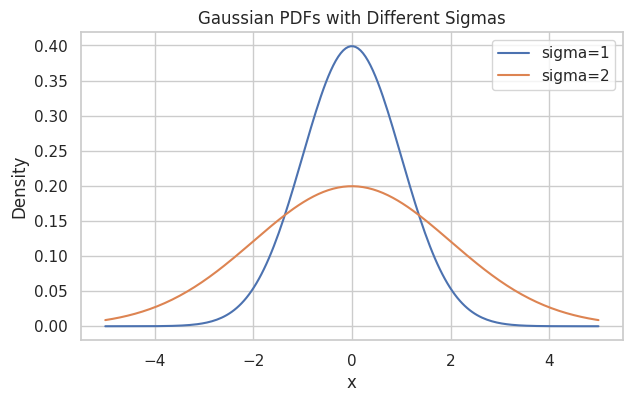

In [ ]:
# -----------------------------------------------------------
# 1. Poisson(mu=2) samples + mean
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pois = stats.poisson(mu=2).rvs(size=10_000)

print("Sample Mean =", round(pois.mean(), 3))

# -----------------------------------------------------------
# 2. Histogram of Poisson samples
# -----------------------------------------------------------

plt.figure(figsize=(7,4))
plt.hist(pois,
         bins=range(0, max(pois)+2),
         density=True,
         edgecolor='black')

plt.title("Poisson Distribution (mu=2)")
plt.xlabel("Count")
plt.ylabel("Probability")
plt.show()

# -----------------------------------------------------------
# 3. Gaussian PDF with two sigmas
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)

plt.figure(figsize=(7,4))

plt.plot(
    x,
    stats.norm(0, 1).pdf(x),
    label='sigma=1'
)

plt.plot(
    x,
    stats.norm(0, 2).pdf(x),
    label='sigma=2'
)

plt.title("Gaussian PDFs with Different Sigmas")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
# -----------------------------------------------------------
# 1. Entropy of fair 4-sided and 6-sided dice
# -----------------------------------------------------------

from scipy.stats import entropy
import numpy as np

die4 = [1/4] * 4
die6 = [1/6] * 6

h4 = entropy(die4, base=2)
h6 = entropy(die6, base=2)

print("Entropy (4-sided die):", round(h4, 3), "bits")
print("Entropy (6-sided die):", round(h6, 3), "bits")

if h6 > h4:
    print("6-sided die is more uncertain")

# -----------------------------------------------------------
# 2. KL Divergence D(P || Q)
# -----------------------------------------------------------

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl = entropy(P, Q, base=2)

print("D(P || Q) =", round(kl, 3), "bits")

# -----------------------------------------------------------
# 3. Most / Least Informative Iris Feature
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()

mi = mutual_info_classif(
        iris.data,
        iris.target,
        random_state=0
     )

features = iris.feature_names

for name, score in sorted(zip(features, mi),
                          key=lambda x: -x[1]):
    print(f"{score:.3f}  {name}")

most_feature = features[np.argmax(mi)]
least_feature = features[np.argmin(mi)]

print("\nMost informative :", most_feature)
print("Least informative:", least_feature)

Entropy (4-sided die): 2.0 bits
Entropy (6-sided die): 2.585 bits
6-sided die is more uncertain
D(P || Q) = 0.119 bits
0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)

Most informative : petal length (cm)
Least informative: sepal width (cm)


In [ ]:
import pandas as pd
import numpy as np

# ==========================================================
# 1. BASIC PANDAS DATA STRUCTURES
# ==========================================================

# Create a Series
s = pd.Series([10, 20, 30, 40], index=['a', 'b', 'c', 'd'])

print("Series:")
print(s)

# Create a DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 40],
    'Salary': [50000, 60000, 70000, 80000]
}

df = pd.DataFrame(data)

print("\nDataFrame:")
print(df)

# ==========================================================
# 2. CONVERT NUMPY ARRAY TO DATAFRAME
# ==========================================================

array = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

df_from_array = pd.DataFrame(
    array,
    columns=['Column1', 'Column2']
)

print("\nDataFrame from NumPy Array:")
print(df_from_array)

# ==========================================================
# 3. DATAFRAME INFORMATION
# ==========================================================

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nInfo:")
df.info()

print("\nStatistics:")
print(df.describe())

# ==========================================================
# 4. INDEXING USING loc[]
# ==========================================================

print("\nRow with label 1:")
print(df.loc[1])

print("\nRows 1 to 3:")
print(df.loc[1:3])

# ==========================================================
# 5. INDEXING USING iloc[]
# ==========================================================

print("\nFirst Two Rows:")
print(df.iloc[0:2])

print("\nFirst Row:")
print(df.iloc[0])

print("\nValue at Row 2 Column 1:")
print(df.iloc[2, 1])

# ==========================================================
# 6. COLUMN SELECTION
# ==========================================================

print("\nName Column:")
print(df['Name'])

print("\nName and Age Columns:")
print(df[['Name', 'Age']])

# ==========================================================
# 7. FILTERING ROWS
# ==========================================================

print("\nSalary > 60000:")
print(df[df['Salary'] > 60000])

print("\nAge > 30:")
print(df[df['Age'] > 30])

print("\nAge > 30 AND Salary > 60000:")
print(
    df[
        (df['Age'] > 30) &
        (df['Salary'] > 60000)
    ]
)

print("\nAge < 30 OR Salary > 70000:")
print(
    df[
        (df['Age'] < 30) |
        (df['Salary'] > 70000)
    ]
)

# ==========================================================
# 8. ADD NEW COLUMN
# ==========================================================

df['Bonus'] = df['Salary'] * 0.10

print("\nAfter Adding Bonus Column:")
print(df)

# ==========================================================
# 9. SORTING
# ==========================================================

print("\nSort by Salary Ascending:")
print(df.sort_values('Salary'))

print("\nSort by Salary Descending:")
print(df.sort_values('Salary', ascending=False))

# ==========================================================
# 10. GROUPBY
# ==========================================================

df['Department'] = ['IT', 'IT', 'HR', 'HR']

print("\nAverage Salary by Department:")
print(
    df.groupby('Department')['Salary'].mean()
)

print("\nTotal Salary by Department:")
print(
    df.groupby('Department')['Salary'].sum()
)

print("\nMultiple Aggregations:")
print(
    df.groupby('Department')['Salary']
      .agg(['sum', 'mean', 'max', 'min'])
)

# ==========================================================
# 11. VALUE COUNTS
# ==========================================================

print("\nDepartment Counts:")
print(df['Department'].value_counts())

# ==========================================================
# 12. UNIQUE VALUES
# ==========================================================

print("\nUnique Departments:")
print(df['Department'].unique())

print("\nNumber of Unique Departments:")
print(df['Department'].nunique())

# ==========================================================
# 13. MISSING VALUES
# ==========================================================

df_missing = df.copy()

df_missing.loc[1, 'Salary'] = np.nan
df_missing.loc[3, 'Age'] = np.nan

print("\nMissing Values Per Column:")
print(df_missing.isna().sum())

print("\nTotal Missing Values:")
print(df_missing.isna().sum().sum())

# Fill Missing Values

df_filled = df_missing.copy()

df_filled['Salary'] = df_filled['Salary'].fillna(
    df_filled['Salary'].mean()
)

df_filled['Age'] = df_filled['Age'].fillna(
    df_filled['Age'].median()
)

print("\nAfter Filling Missing Values:")
print(df_filled)

# Drop Missing Values

print("\nAfter Dropping Missing Values:")
print(df_missing.dropna())

# ==========================================================
# 14. DUPLICATES
# ==========================================================

df_dup = pd.concat(
    [df, df.iloc[[0]]],
    ignore_index=True
)

print("\nDuplicate Rows:")
print(df_dup.duplicated().sum())

print("\nAfter Removing Duplicates:")
print(df_dup.drop_duplicates())

# ==========================================================
# 15. STRING OPERATIONS
# ==========================================================

cities = pd.Series(
    [' Pune ', 'DELHI', 'Mumbai', 'bombay']
)

print("\nStrip:")
print(cities.str.strip())

print("\nLower:")
print(cities.str.lower())

print("\nReplace:")
print(
    cities.str.lower().replace(
        {'bombay': 'mumbai'}
    )
)

# ==========================================================
# 16. TYPE CONVERSION
# ==========================================================

sales = pd.Series(
    ['100', '200', 'N/A', '400']
)

sales_numeric = pd.to_numeric(
    sales,
    errors='coerce'
)

print("\nNumeric Conversion:")
print(sales_numeric)

dates = pd.Series([
    '2024-01-01',
    '2024-01-02',
    '2024-01-03'
])

dates = pd.to_datetime(dates)

print("\nDate Conversion:")
print(dates)

# ==========================================================
# 17. CORRELATION
# ==========================================================

print("\nCorrelation Matrix:")
print(
    df[['Age', 'Salary', 'Bonus']]
      .corr()
)

# ==========================================================
# 18. SAVE & READ CSV
# ==========================================================

df.to_csv(
    'employees.csv',
    index=False
)

df_read = pd.read_csv(
    'employees.csv'
)

print("\nRead CSV:")
print(df_read.head())

# ==========================================================
# END OF PROGRAM
# ==========================================================

Series:
a    10
b    20
c    30
d    40
dtype: int64

DataFrame:
      Name  Age  Salary
0    Alice   25   50000
1      Bob   30   60000
2  Charlie   35   70000
3    David   40   80000

DataFrame from NumPy Array:
   Column1  Column2
0        1        2
1        3        4
2        5        6

Shape:
(4, 3)

Columns:
Index(['Name', 'Age', 'Salary'], dtype='object')

Data Types:
Name      object
Age        int64
Salary     int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    4 non-null      object
 1   Age     4 non-null      int64 
 2   Salary  4 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 228.0+ bytes

Statistics:
             Age        Salary
count   4.000000      4.000000
mean   32.500000  65000.000000
std     6.454972  12909.944487
min    25.000000  50000.000000
25%    28.750000  57500.000000
50%    32.500